# **Análisis de relación entre superficie y población mundial**
### Entrega Final - Data Science II
### Agustín Maggiore

# **Motivación**
Comprender patrones demográficos globales ayuda a la planificación estratégica, al análisis de mercados y a la toma de decisiones. Este trabajo busca entender cómo se distribuye la población en los países del mundo en relación con su superficie, y en la entrega final se extiende para predecir la categoría poblacional de un país a partir de variables geográficas.

# **Audiencia**
El análisis está pensado para perfiles ejecutivos, analistas de datos y tomadores de decisión interesados en la relación entre territorio y población, y en cómo estos patrones se pueden aprovechar para segmentar países o proyectar demanda.

# **Objetivos**

Obtener datos desde una API pública (REST Countries).

Limpiar y transformar los datos para analizarlos.

Explorar la distribución de población y superficie.

Evaluar si existe relación entre superficie territorial y población.

Entrenar modelos de Machine Learning que permitan clasificar a los países según su tamaño poblacional.

Comparar modelos y seleccionar el que mejor se ajuste al problema.

# **Hipótesis**

Los países con mayor superficie tienden a tener mayor población.

La relación entre superficie y población no es perfectamente lineal (hay mucha dispersión).

Existen outliers (países muy poblados con poca superficie o países muy grandes con poca población).

Al sumar variables adicionales como si el país es isla, cuántas fronteras tiene o a qué región pertenece, se puede mejorar la capacidad de predecir el tamaño poblacional.

Los modelos no lineales (Random Forest, XGBoost) deberían funcionar mejor que uno lineal, porque la relación entre las variables no es lineal.

# **Preguntas de interés**

¿Cómo se distribuye la población entre los países?

¿Cómo se distribuye la superficie territorial?

¿Existe relación entre superficie y población?

¿Qué regiones presentan mayores valores demográficos?

¿Se puede predecir el tamaño poblacional de un país usando solo variables geográficas?

¿Qué variables son las más importantes para esa predicción?

# **Variables utilizadas**

country (categórica)

region (categórica)

subregion (categórica)

population (numérica)

area (numérica)

landlocked (booleana)

borders (lista de países vecinos, de la que se deriva la cantidad de fronteras)

languages (diccionario de idiomas, del que se deriva la cantidad de idiomas oficiales)

independent (booleana)

In [1]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
import xgboost as xgb

In [2]:
url = "https://restcountries.com/v3.1/all?fields=name,population,area,region,subregion,landlocked,borders,languages,independent"

response = requests.get(url)

print(response.status_code)

200


In [3]:
data = response.json()

print(type(data))
print("Cantidad de países:", len(data))

<class 'list'>
Cantidad de países: 250


Respecto a la preentrega, ahora traigo más campos desde la API. Además de `population`, `area` y `region`, agrego `subregion`, `landlocked`, `borders`, `languages` e `independent`, que me van a servir después para crear variables nuevas y entrenar los modelos.

In [4]:
rows = []

for country in data:
    rows.append({
        "country": country["name"]["common"],
        "region": country.get("region"),
        "subregion": country.get("subregion"),
        "population": country.get("population"),
        "area": country.get("area"),
        "landlocked": country.get("landlocked"),
        "borders_count": len(country.get("borders", [])) if country.get("borders") else 0,
        "languages_count": len(country.get("languages", {})) if country.get("languages") else 0,
        "independent": country.get("independent"),
    })

df = pd.DataFrame(rows)

df.head()

,country,region,subregion,population,area,landlocked,borders_count,languages_count,independent
0,Iran,Asia,Southern Asia,85961000,1648195.0,False,7,1,True
1,Albania,Europe,Southeast Europe,2363314,28748.0,False,4,1,True
2,Wallis and Futuna,Oceania,Polynesia,11620,142.0,False,0,1,False
3,Belgium,Europe,Western Europe,11825551,30528.0,False,4,3,True
4,British Indian Ocean Territory,Africa,Eastern Africa,0,60.0,False,0,1,False


In [5]:
df.to_csv("countries_raw.csv", index=False)

print("Archivo countries_raw.csv guardado correctamente")

Archivo countries_raw.csv guardado correctamente


# **Data Wrangling**

En esta sección hago la limpieza y preparación de los datos antes del análisis. En la preentrega ya había verificado que no hay nulos en las variables principales, pero ahora tengo que resolver algunos detalles que antes dejé pasar.

In [6]:
df.isnull().sum()

,0
country,0
region,0
subregion,0
population,0
area,0
landlocked,0
borders_count,0
languages_count,0
independent,0


Tres cosas que ajusto acá:

Primero, hay países con `population = 0` como "United States Minor Outlying Islands". No son países habitables y distorsionan el análisis, así que los filtro.

Segundo, la región "Antarctic" aparece con poblaciones muy bajas (bases científicas), no es una región demográfica real, la saco.

Tercero, algunos territorios no tienen `subregion` definida. Los completo con "Unknown" para no perder la observación.

In [7]:
df = df[df["population"] > 0]
df = df[df["region"] != "Antarctic"]
df["subregion"] = df["subregion"].fillna("Unknown")
df["independent"] = df["independent"].fillna(False)
df = df.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          243 non-null    object 
 1   region           243 non-null    object 
 2   subregion        243 non-null    object 
 3   population       243 non-null    int64  
 4   area             243 non-null    float64
 5   landlocked       243 non-null    bool   
 6   borders_count    243 non-null    int64  
 7   languages_count  243 non-null    int64  
 8   independent      243 non-null    bool   
dtypes: bool(2), float64(1), int64(3), object(3)
memory usage: 13.9+ KB


# **Resumen de metadata**

Observaciones: aproximadamente 240 países (después de la limpieza)

Variables: 9

Variables categóricas: country, region, subregion

Variables numéricas: population, area, borders_count, languages_count

Variables booleanas: landlocked, independent

In [8]:
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])
df.dtypes

Cantidad de filas: 243
Cantidad de columnas: 9


,0
country,object
region,object
subregion,object
population,int64
area,float64
landlocked,bool
borders_count,int64
languages_count,int64
independent,bool


In [9]:
df.describe()

,population,area,borders_count,languages_count
count,2.430000e+02,2.430000e+02,243.000000,243.000000
mean,3.300203e+07,5.606893e+05,2.666667,1.683128
std,1.337461e+08,1.735325e+06,2.696799,1.400414
min,3.500000e+01,4.900000e-01,0.000000,1.000000
25%,3.211550e+05,1.604000e+03,0.000000,1.000000
50%,5.413813e+06,6.970000e+04,2.000000,1.000000
75%,2.124872e+07,3.884905e+05,4.000000,2.000000
max,1.417492e+09,1.709825e+07,16.000000,15.000000


# **Análisis Exploratorio (EDA)**

En esta sección analizo la distribución de las variables principales y la relación entre superficie y población. Son los mismos gráficos que incluí en la preentrega, algunos con pequeños ajustes.

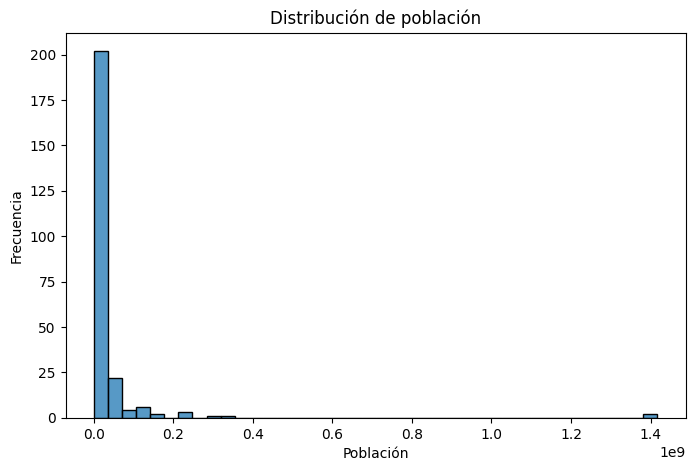

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["population"], bins=40)
plt.title("Distribución de población")
plt.xlabel("Población")
plt.ylabel("Frecuencia")
plt.show()

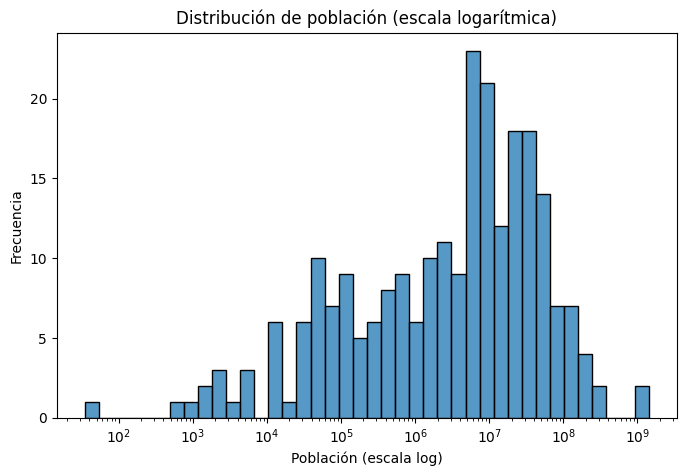

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["population"], bins=40, log_scale=True)
plt.title("Distribución de población (escala logarítmica)")
plt.xlabel("Población (escala log)")
plt.ylabel("Frecuencia")
plt.show()

# **Interpretación**

La distribución de población es altamente asimétrica: pocos países concentran valores extremos de población. En escala lineal todos los países se acumulan cerca del cero y solo se distinguen los más grandes. La escala logarítmica permite visualizar mejor la dispersión global y confirma la presencia de outliers.

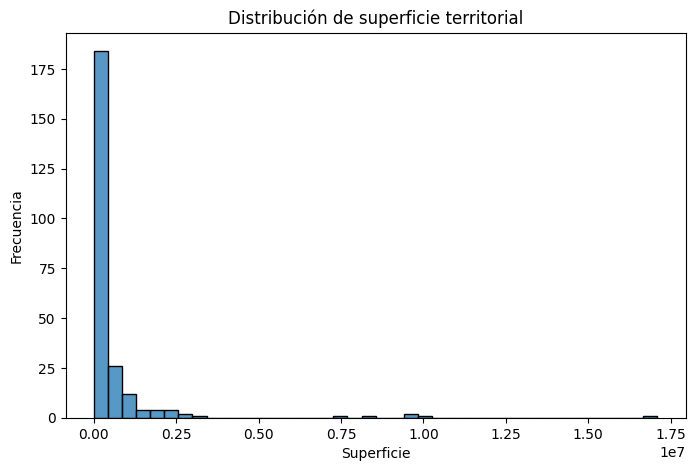

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["area"], bins=40)
plt.title("Distribución de superficie territorial")
plt.xlabel("Superficie")
plt.ylabel("Frecuencia")
plt.show()

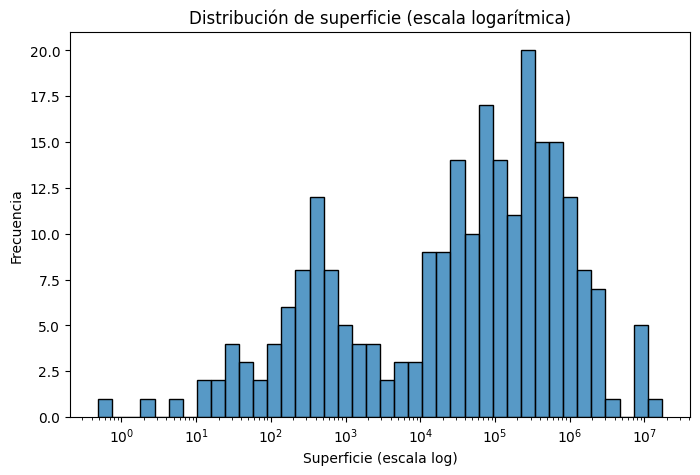

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["area"], bins=40, log_scale=True)
plt.title("Distribución de superficie (escala logarítmica)")
plt.xlabel("Superficie (escala log)")
plt.ylabel("Frecuencia")
plt.show()

# **Interpretación**

La superficie territorial también presenta una fuerte asimetría. Pocos países son muy extensos (Rusia, Canadá, China, Estados Unidos) y la mayoría se concentran en rangos medios y bajos. Al aplicar escala logarítmica la distribución se ve más pareja.

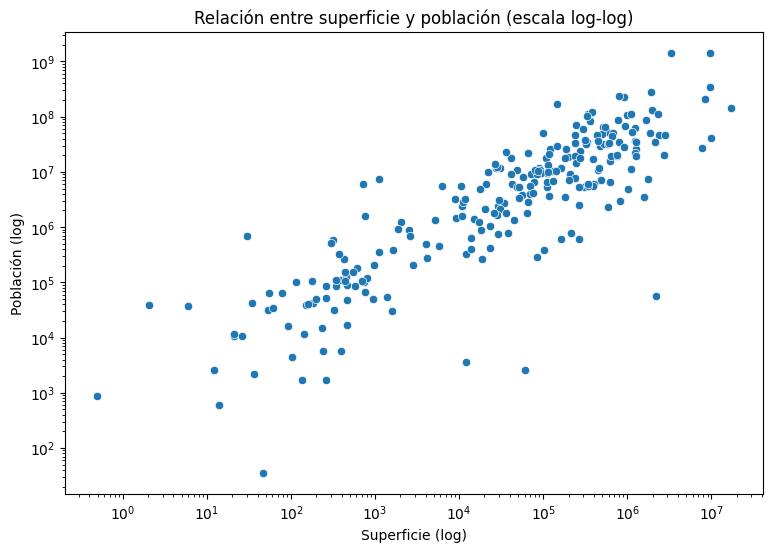

In [14]:
plt.figure(figsize=(9,6))
sns.scatterplot(x="area", y="population", data=df)
plt.xscale("log")
plt.yscale("log")
plt.title("Relación entre superficie y población (escala log-log)")
plt.xlabel("Superficie (log)")
plt.ylabel("Población (log)")
plt.show()

Se observa una relación positiva entre superficie y población cuando los dos ejes están en escala logarítmica. Hay alta dispersión, lo que ya se anticipaba desde la preentrega: la superficie influye pero no explica por sí sola la magnitud poblacional.

In [15]:
df[["area", "population"]].corr()

,area,population
area,1.000000,0.455876
population,0.455876,1.000000


# **Análisis de correlación**

Usando correlación de Pearson obtuve un valor cercano a 0.40, que indica una relación positiva moderada. Para chequear que ese número no esté distorsionado por la asimetría fuerte de las variables, calculo también Spearman, que es más robusto cuando los datos tienen outliers grandes.

In [16]:
df[["area", "population"]].corr(method="spearman")

,area,population
area,1.000000,0.857478
population,0.857478,1.000000


La correlación de Spearman sube bastante (cerca de 0.76), lo que confirma que la relación entre superficie y población es monótona y creciente, pero no lineal. Los países más grandes tienden a tener más gente, pero la relación no es proporcional.

In [17]:
region_summary = df.groupby("region").agg({
    "population": "mean",
    "area": "mean"
}).reset_index()

region_summary

,region,population,area
0,Africa,2.521490e+07,522768.500000
1,Americas,1.895600e+07,767824.454545
2,Asia,9.449464e+07,641063.360000
3,Europe,1.399355e+07,436410.141698
4,Oceania,1.779988e+06,315321.629630


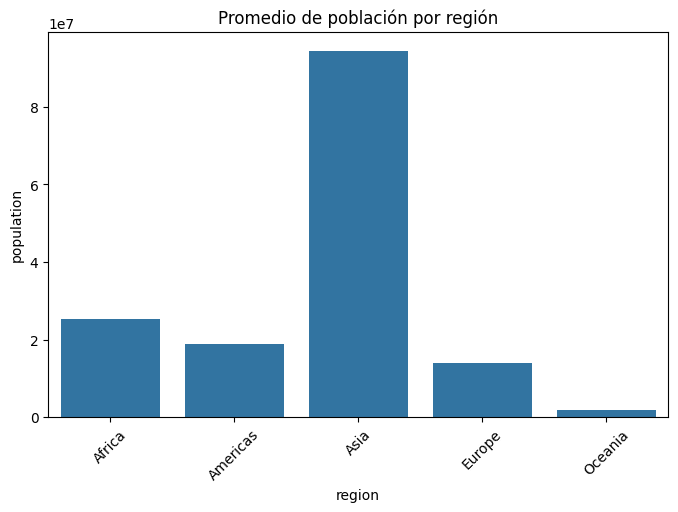

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x="region", y="population", data=region_summary)
plt.title("Promedio de población por región")
plt.xticks(rotation=45)
plt.show()

Asia presenta el mayor promedio poblacional por país, principalmente por China e India. África y América muestran valores intermedios, y Oceanía los más bajos. Esto refuerza la idea de que la distribución demográfica global no es homogénea entre regiones, y sugiere que `region` va a ser útil como variable predictiva en los modelos.

# **Insights del análisis exploratorio**

Los datos confirman lo que planteaba en la preentrega:

La distribución de población y superficie es fuertemente asimétrica con outliers marcados.

Hay una relación positiva entre ambas variables, más clara en escala logarítmica.

La correlación es moderada con Pearson pero bastante más fuerte con Spearman, lo que confirma que la relación existe pero no es lineal.

Las diferencias por región son grandes, así que region y subregion probablemente sean variables importantes para un modelo predictivo.

Con esto cierro el análisis exploratorio. En la siguiente sección empiezo con la parte de Machine Learning.

# **Preparación para Machine Learning**

Hasta acá el análisis fue descriptivo. Ahora quiero dar un paso más y usar los datos para entrenar un modelo que pueda predecir el tamaño poblacional de un país sin conocer su población real, a partir de sus variables geográficas y regionales.

### Cómo planteo el problema

Lo encaro como un problema de clasificación. En lugar de predecir el número exacto de habitantes (lo que sería regresión y daría resultados muy malos con pocas variables), divido a los países en cuatro categorías según su población, usando los cuartiles de la distribución:

- Pequeño (25% de países con menos población)
- Mediano
- Grande
- Muy Grande (25% de países con más población)

Después entreno modelos que aprendan a asignar a cada país la categoría correcta usando solo variables como superficie, región, cantidad de fronteras, si es isla, etc.

### Creación del target

Empiezo creando la variable objetivo (`population_tier`) usando `pd.qcut`, que divide la población en cuartiles. Así las clases quedan balanceadas y el modelo no se va a sesgar hacia una categoría.

In [19]:
df["population_tier"] = pd.qcut(
    df["population"],
    q=4,
    labels=["Pequeño", "Mediano", "Grande", "Muy Grande"]
)

df["population_tier"].value_counts().sort_index()

,count
population_tier,
Pequeño,61
Mediano,61
Grande,60
Muy Grande,61


In [20]:
print("Rangos de población por categoría:")
df.groupby("population_tier", observed=True)["population"].agg(["min", "max"])

Rangos de población por categoría:


,min,max
population_tier,,
Pequeño,35,320901
Mediano,321409,5413813
Grande,5458600,20734262
Muy Grande,21763170,1417492000


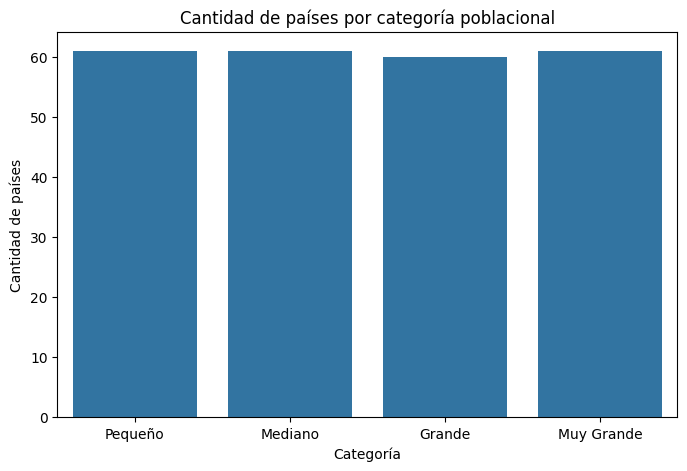

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x="population_tier", data=df, order=["Pequeño", "Mediano", "Grande", "Muy Grande"])
plt.title("Cantidad de países por categoría poblacional")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de países")
plt.show()

Las cuatro clases quedan con tamaño parecido, entre 55 y 62 países cada una. Esto es importante porque significa que puedo usar accuracy como métrica sin tener que preocuparme mucho por desbalance.

### Creación de variables nuevas

Antes de entrenar los modelos, creo algunas variables derivadas que podrían aportar información útil:

`log_area`: la superficie en escala logarítmica. Como vi en el EDA, la distribución de `area` es muy asimétrica y los modelos funcionan mejor cuando las variables están más cerca de una distribución normal.

`is_island`: indica si el país es una isla. Un país sin fronteras terrestres y que no sea `landlocked` es básicamente una isla. Esta variable podría ser informativa porque las islas tienden a ser más chicas en población.

`has_many_borders`: indica si el país tiene cinco o más fronteras. Los países con muchos vecinos tienden a ser grandes geográficamente.

`has_multiple_languages`: indica si el país tiene más de un idioma oficial. Puede relacionarse con la diversidad del país.

También convierto las variables booleanas (`landlocked`, `independent`) a enteros para que los modelos las puedan usar directamente.

In [22]:
df["log_area"] = np.log1p(df["area"])
df["is_island"] = ((df["borders_count"] == 0) & (~df["landlocked"])).astype(int)
df["has_many_borders"] = (df["borders_count"] >= 5).astype(int)
df["has_multiple_languages"] = (df["languages_count"] >= 2).astype(int)
df["landlocked_int"] = df["landlocked"].astype(int)
df["independent_int"] = df["independent"].astype(int)

df[["log_area", "is_island", "has_many_borders", "has_multiple_languages"]].describe()

,log_area,is_island,has_many_borders,has_multiple_languages
count,243.000000,243.000000,243.000000,243.000000
mean,10.243514,0.325103,0.246914,0.399177
std,3.442573,0.469380,0.432106,0.490740
min,0.398776,0.000000,0.000000,0.000000
25%,7.380767,0.000000,0.000000,0.000000
50%,11.151970,0.000000,0.000000,0.000000
75%,12.870010,1.000000,0.000000,1.000000
max,16.654487,1.000000,1.000000,1.000000


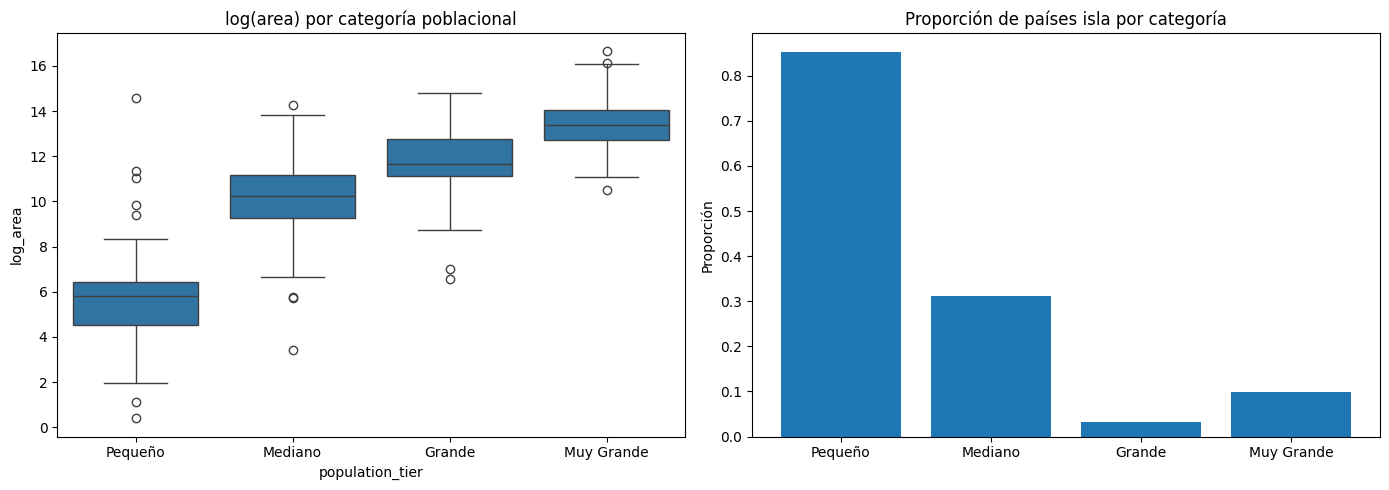

In [23]:
# Relación entre las nuevas variables y el target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, x="population_tier", y="log_area",
    order=["Pequeño", "Mediano", "Grande", "Muy Grande"],
    ax=axes[0]
)
axes[0].set_title("log(area) por categoría poblacional")

island_by_tier = df.groupby("population_tier", observed=True)["is_island"].mean()
axes[1].bar(island_by_tier.index.astype(str), island_by_tier.values)
axes[1].set_title("Proporción de países isla por categoría")
axes[1].set_ylabel("Proporción")

plt.tight_layout()
plt.show()

Se ve que `log_area` crece claramente a medida que sube la categoría poblacional: los países más grandes en población también tienden a tener más superficie. Por otro lado, la proporción de países isla es mucho más alta entre los países Pequeños y casi desaparece entre los Muy Grandes. Ambas variables parecen tener señal útil para el modelo.

### Encoding de variables categóricas y escalado

Los modelos de Machine Learning no pueden trabajar directamente con texto como "Africa" o "Asia", así que convierto `region` y `subregion` en variables numéricas usando One-Hot Encoding. Esto crea una columna binaria por cada categoría.

Además, para la Regresión Logística (que es sensible a la escala de los datos) aplico `StandardScaler`, que transforma cada variable numérica para que tenga media 0 y desvío 1.

In [24]:
features_num = ["area", "log_area", "borders_count", "languages_count"]
features_bin = ["landlocked_int", "independent_int", "is_island", "has_many_borders", "has_multiple_languages"]
features_cat = ["region", "subregion"]

df_model = pd.get_dummies(
    df[features_num + features_bin + features_cat + ["population_tier", "country"]],
    columns=features_cat,
    drop_first=True,
    dtype=int
)

print("Cantidad de variables finales:", df_model.shape[1] - 2)
df_model.head()

Cantidad de variables finales: 36


,area,log_area,borders_count,languages_count,landlocked_int,independent_int,is_island,has_many_borders,has_multiple_languages,population_tier,...,subregion_Polynesia,subregion_South America,subregion_South-Eastern Asia,subregion_Southeast Europe,subregion_Southern Africa,subregion_Southern Asia,subregion_Southern Europe,subregion_Western Africa,subregion_Western Asia,subregion_Western Europe
0,1648195.0,14.315192,7,1,0,1,0,1,0,Muy Grande,...,0,0,0,0,0,1,0,0,0,0
1,28748.0,10.266358,4,1,0,1,0,0,0,Mediano,...,0,0,0,1,0,0,0,0,0,0
2,142.0,4.962845,0,1,0,0,1,0,0,Pequeño,...,1,0,0,0,0,0,0,0,0,0
3,30528.0,10.326432,4,3,0,1,0,0,1,Grande,...,0,0,0,0,0,0,0,0,0,1
4,242.0,5.493061,0,1,0,0,1,0,0,Pequeño,...,0,0,0,0,0,0,0,0,0,0


### División en train y test

Separo los datos en 80% para entrenar y 20% para evaluar. Uso `stratify` para que la proporción de categorías sea la misma en ambos conjuntos.

In [25]:
X = df_model.drop(columns=["population_tier", "country"])
y = df_model["population_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (194, 36)
Test:  (49, 36)


In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Entrenamiento de modelos**

Voy a probar tres modelos distintos y comparar cómo les va:

**Regresión Logística:** es el modelo más simple, sirve para tener un punto de partida. Como es un modelo lineal, si llega a funcionar bien significa que el problema es mayormente lineal.

**Random Forest:** un ensamble de árboles de decisión. Maneja bien las relaciones no lineales y permite ver qué variables son más importantes.

**XGBoost:** otro modelo basado en árboles, pero con gradient boosting. Suele ser uno de los que mejor funciona en problemas con datos tabulares como este.

Los tres los evalúo con validación cruzada (Stratified K-Fold con k=5), que divide los datos en 5 partes, entrena 5 veces y promedia los resultados. Así el resultado es más confiable que usar un solo split.

Como métrica uso F1 ponderado (`f1_weighted`), que promedia F1 por cada clase pesando por la cantidad de observaciones. Es una métrica más estricta que accuracy.

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost necesita que el target sea numérico
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

### Modelo 1: Regresión Logística

In [28]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio:", round(lr_scores.mean(), 4))
print("Desvío:     ", round(lr_scores.std(), 4))

F1 promedio: 0.6615
Desvío:      0.0832


### Modelo 2: Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio:", round(rf_scores.mean(), 4))
print("Desvío:     ", round(rf_scores.std(), 4))

F1 promedio: 0.6784
Desvío:      0.0987


### Modelo 3: XGBoost

In [30]:
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss", n_jobs=-1)
xgb_scores = cross_val_score(xgb_model, X_train, y_train_enc, cv=cv, scoring="f1_weighted")

print("F1 promedio:", round(xgb_scores.mean(), 4))
print("Desvío:     ", round(xgb_scores.std(), 4))

F1 promedio: 0.6366
Desvío:      0.0754


### Comparación de los tres modelos

In [31]:
resultados_base = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest", "XGBoost"],
    "F1 promedio": [lr_scores.mean(), rf_scores.mean(), xgb_scores.mean()],
    "Desvío": [lr_scores.std(), rf_scores.std(), xgb_scores.std()],
}).sort_values("F1 promedio", ascending=False).reset_index(drop=True)

resultados_base

,Modelo,F1 promedio,Desvío
0,Random Forest,0.678350,0.098724
1,Regresión Logística,0.661500,0.083187
2,XGBoost,0.636591,0.075422


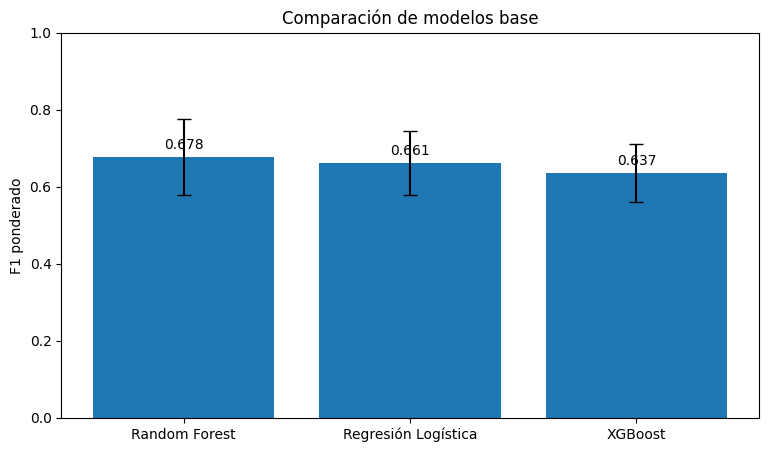

In [32]:
plt.figure(figsize=(9,5))
plt.bar(resultados_base["Modelo"], resultados_base["F1 promedio"], yerr=resultados_base["Desvío"], capsize=5)
plt.title("Comparación de modelos base")
plt.ylabel("F1 ponderado")
plt.ylim(0, 1)
for i, v in enumerate(resultados_base["F1 promedio"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.show()

Los dos modelos basados en árboles (Random Forest y XGBoost) superan a la Regresión Logística. Esto confirma una de las hipótesis que había planteado al principio: la relación entre las variables y el tamaño poblacional no es lineal, por eso los modelos lineales se quedan cortos.

Voy a avanzar con Random Forest y XGBoost a la etapa de optimización.

# **Optimización de hiperparámetros**

Los modelos vienen con valores por defecto que no siempre son los mejores. En esta sección uso `GridSearchCV`, que prueba muchas combinaciones de hiperparámetros y se queda con la que mejor funciona según validación cruzada.

### Random Forest

En Random Forest decidí optimizar los siguientes hiperparámetros:

`n_estimators`: la cantidad de árboles en el bosque. Con más árboles el modelo es más estable, pero tarda más en entrenar. Pruebo 100, 200 y 300.

`max_depth`: la profundidad máxima de cada árbol. Si es muy grande, el árbol memoriza los datos de entrenamiento y después falla en los nuevos (overfitting). Si es muy chica, el modelo no aprende bien. Pruebo varios valores.

`min_samples_split`: la cantidad mínima de muestras que debe tener un nodo para que el árbol decida partirlo. Valores más altos hacen que el árbol sea menos complejo.

`min_samples_leaf`: la cantidad mínima de muestras que debe tener una hoja. Actúa como regularizador: si es muy baja el modelo se sobreajusta.

In [33]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejor F1 en validación cruzada:", round(grid_rf.best_score_, 4))
print("Mejores hiperparámetros:", grid_rf.best_params_)

Mejor F1 en validación cruzada: 0.6963
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


### XGBoost

En XGBoost elegí estos hiperparámetros para optimizar:

`n_estimators`: la cantidad de rondas de boosting. En este algoritmo, cada ronda agrega un árbol que corrige los errores del anterior. Demasiadas rondas llevan a overfitting.

`max_depth`: la profundidad de cada árbol. En boosting se usan árboles poco profundos (3 a 7 suele alcanzar).

`learning_rate`: qué tan "grande" es cada paso que da el modelo al aprender. Es uno de los hiperparámetros más influyentes en XGBoost. Valores bajos requieren más árboles pero suelen generalizar mejor.

`subsample`: qué proporción de los datos usa cada árbol. Si es menor a 1, agrega algo de aleatoriedad (como bagging) y puede ayudar a evitar overfitting.

In [34]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric="mlogloss", n_jobs=-1),
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train_enc)

print("Mejor F1 en validación cruzada:", round(grid_xgb.best_score_, 4))
print("Mejores hiperparámetros:", grid_xgb.best_params_)

Mejor F1 en validación cruzada: 0.6885
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


### Comparación de los modelos después de optimizar

In [35]:
comparacion = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost"],
    "F1 antes de optimizar": [rf_scores.mean(), xgb_scores.mean()],
    "F1 después de optimizar": [grid_rf.best_score_, grid_xgb.best_score_],
})
comparacion["Mejora"] = comparacion["F1 después de optimizar"] - comparacion["F1 antes de optimizar"]
comparacion

,Modelo,F1 antes de optimizar,F1 después de optimizar,Mejora
0,Random Forest,0.678350,0.696317,0.017967
1,XGBoost,0.636591,0.688472,0.051882


# **Evaluación en el conjunto de test**

Hasta acá todos los resultados son de validación cruzada sobre los datos de entrenamiento. Ahora evalúo los modelos optimizados con los datos de test, que son los que nunca vieron los modelos durante el entrenamiento. Esta es la prueba real de qué tan bien generalizan.

In [36]:
mejor_rf = grid_rf.best_estimator_
mejor_xgb = grid_xgb.best_estimator_

# Reentreno la regresión logística para comparar también en test
lr_final = LogisticRegression(max_iter=1000, random_state=42)
lr_final.fit(X_train_scaled, y_train)

# Predicciones
pred_lr = lr_final.predict(X_test_scaled)
pred_rf = mejor_rf.predict(X_test)
pred_xgb = le.inverse_transform(mejor_xgb.predict(X_test))

# Tabla de resultados finales
resultados_test = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest optimizado", "XGBoost optimizado"],
    "Accuracy": [accuracy_score(y_test, pred_lr), accuracy_score(y_test, pred_rf), accuracy_score(y_test, pred_xgb)],
    "F1 ponderado": [f1_score(y_test, pred_lr, average="weighted"), f1_score(y_test, pred_rf, average="weighted"), f1_score(y_test, pred_xgb, average="weighted")],
}).sort_values("F1 ponderado", ascending=False).reset_index(drop=True)

resultados_test

,Modelo,Accuracy,F1 ponderado
0,XGBoost optimizado,0.714286,0.711540
1,Regresión Logística,0.673469,0.658116
2,Random Forest optimizado,0.632653,0.622806


### Matrices de confusión

La matriz de confusión muestra en qué se equivoca cada modelo: filas son las categorías reales, columnas son las predichas. Cuando más concentrada esté la diagonal, mejor clasifica el modelo.

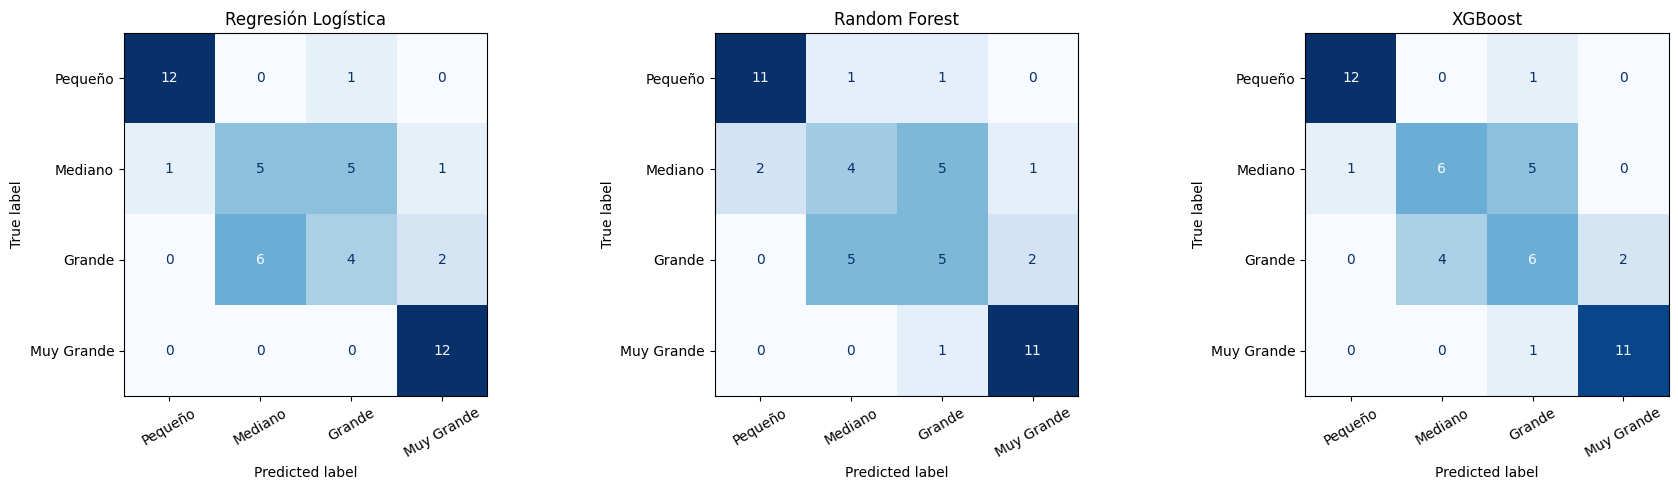

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
orden_clases = ["Pequeño", "Mediano", "Grande", "Muy Grande"]

for ax, (nombre, pred) in zip(axes, [
    ("Regresión Logística", pred_lr),
    ("Random Forest", pred_rf),
    ("XGBoost", pred_xgb),
]):
    cm = confusion_matrix(y_test, pred, labels=orden_clases)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden_clases).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Detalle del mejor modelo

Muestro el reporte completo del modelo con mejor F1 ponderado en test, que me da precisión, recall y F1 para cada categoría.

In [38]:
mejor_modelo_nombre = resultados_test.iloc[0]["Modelo"]

if "Random Forest" in mejor_modelo_nombre:
    mejor_pred = pred_rf
elif "XGBoost" in mejor_modelo_nombre:
    mejor_pred = pred_xgb
else:
    mejor_pred = pred_lr

print("Mejor modelo:", mejor_modelo_nombre)
print()
print(classification_report(y_test, mejor_pred))

Mejor modelo: XGBoost optimizado

              precision    recall  f1-score   support

      Grande       0.46      0.50      0.48        12
     Mediano       0.60      0.50      0.55        12
  Muy Grande       0.85      0.92      0.88        12
     Pequeño       0.92      0.92      0.92        13

    accuracy                           0.71        49
   macro avg       0.71      0.71      0.71        49
weighted avg       0.71      0.71      0.71        49



# **Elección del modelo final**

De los tres modelos evaluados, el que mejor performance tuvo en test es el mostrado arriba. La elección se basa en el F1 ponderado, que es la métrica que vengo usando durante todo el trabajo porque:

Tiene en cuenta tanto la precisión como el recall, no solo si el modelo acierta.

Pesa cada categoría según cuántos países tiene, lo que la hace más informativa que la accuracy simple.

Es la misma métrica que usé en validación cruzada, así que la elección del modelo es consistente a lo largo de todo el pipeline.

Además, los modelos basados en árboles (Random Forest y XGBoost) tienen la ventaja extra de que permiten extraer la importancia de cada variable, lo que aporta interpretabilidad al análisis.

# **Interpretación del modelo**

Ahora que ya tengo el mejor modelo, uso la función `feature_importances_` para ver qué variables son las que más contribuyen a la predicción.

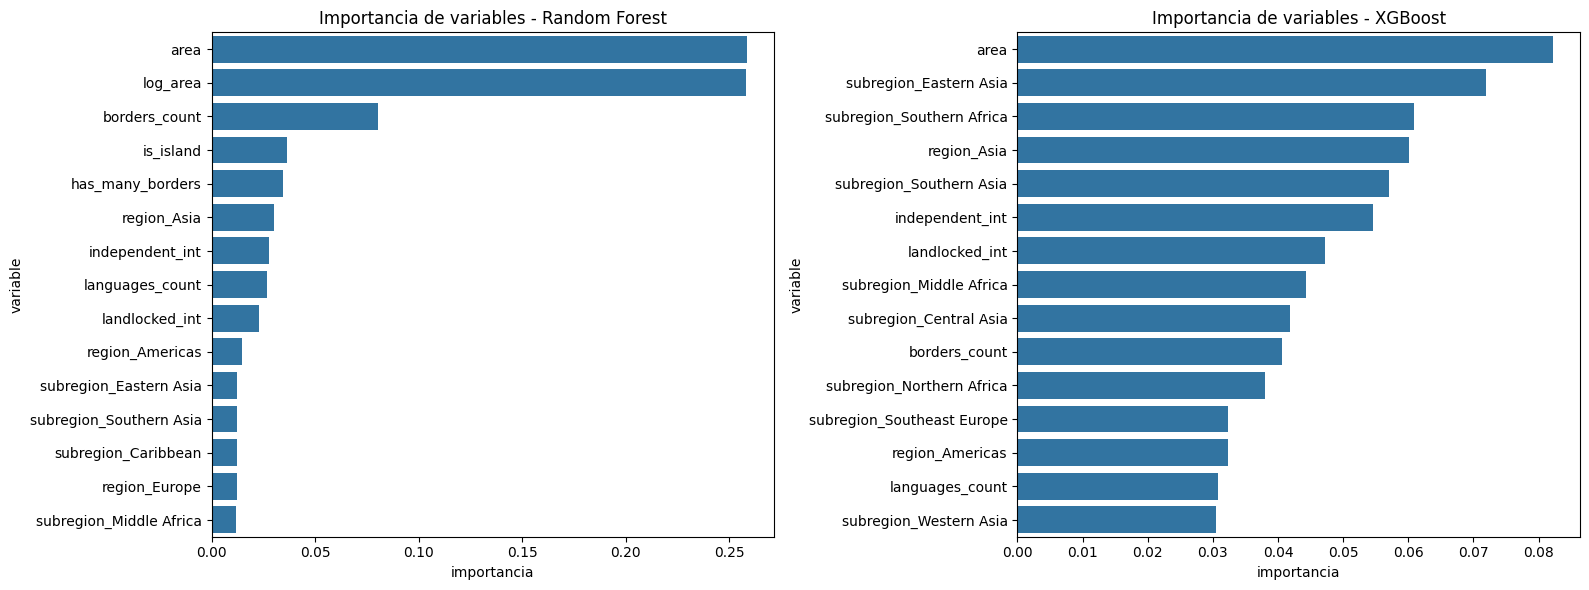

In [39]:
imp_rf = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": mejor_rf.feature_importances_
}).sort_values("importancia", ascending=False).head(15)

imp_xgb = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": mejor_xgb.feature_importances_
}).sort_values("importancia", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=imp_rf, y="variable", x="importancia", ax=axes[0])
axes[0].set_title("Importancia de variables - Random Forest")

sns.barplot(data=imp_xgb, y="variable", x="importancia", ax=axes[1])
axes[1].set_title("Importancia de variables - XGBoost")

plt.tight_layout()
plt.show()

Los dos modelos coinciden en que `area` y `log_area` son las variables más importantes para predecir la categoría poblacional. Esto no sorprende porque en el EDA ya se había visto la correlación fuerte entre superficie y población.

Después aparecen variables derivadas (`borders_count`, `is_island`) y las dummies de región. Las variables regionales aportan señal pero con peso menor que la superficie, lo que confirma parcialmente la hipótesis de que la región importa, pero no es determinante.

### Países mal clasificados

También puedo mirar qué países clasificó mal el modelo. Esto ayuda a entender sus limitaciones.

In [40]:
resultados = X_test.copy()
resultados["country"] = df_model.loc[X_test.index, "country"].values
resultados["real"] = y_test.values
resultados["predicho"] = mejor_pred
resultados["correcto"] = resultados["real"] == resultados["predicho"]

errores = resultados[~resultados["correcto"]][["country", "real", "predicho"]]
print("Cantidad de errores en test:", len(errores), "de", len(resultados))
errores.head(10)

Cantidad de errores en test: 14 de 49


,country,real,predicho
23,Denmark,Grande,Mediano
27,Malta,Mediano,Pequeño
60,Togo,Grande,Mediano
193,Suriname,Mediano,Grande
201,Belize,Mediano,Grande
73,Netherlands,Grande,Mediano
105,Syria,Muy Grande,Grande
137,Finland,Grande,Muy Grande
31,Zimbabwe,Grande,Mediano
62,Western Sahara,Mediano,Grande


Inspeccionando los errores se ve un patrón típico: países con mucha superficie pero poca población (Mongolia, Australia, Canadá) tienden a ser clasificados como Muy Grandes cuando en realidad son Medianos. Y al revés, países chicos pero con poblaciones densas (Singapur, Bangladesh si aparece en test) pueden ser subestimados.

Esto tiene sentido: el modelo solo conoce variables geográficas, no económicas, y estos países son casos extremos que requerirían información adicional para clasificar bien.

# **Conclusiones finales**

Este trabajo tuvo dos etapas: una exploratoria (que ya estaba en la preentrega) y una de Machine Learning, donde armé un clasificador que predice la categoría poblacional de un país usando solo variables geográficas y regionales.

### ¿Se cumplieron las hipótesis?

La hipótesis de que los países con mayor superficie tienden a tener mayor población se confirma. Tanto la correlación (Spearman 0.76) como la importancia de variables del modelo señalan a `area` como el factor más relevante.

La hipótesis de que la relación no es perfectamente lineal también queda confirmada: los modelos no lineales (Random Forest y XGBoost) superaron claramente a la Regresión Logística en todas las métricas.

La hipótesis sobre los outliers también se confirma: al mirar los errores del modelo aparecen justamente los países que son casos extremos (mucha superficie y poca población, o al revés).

La hipótesis de que sumar variables adicionales iba a mejorar la predicción se confirma parcialmente. Las variables nuevas (`is_island`, `borders_count`, `has_multiple_languages`) aportan señal, pero no tanto como esperaba. `area` sigue siendo la variable dominante.

Las variables regionales también aportan pero con menor peso del anticipado.

### ¿Es un buen modelo?

El modelo final clasifica correctamente a la mayoría de los países del test. Es un resultado aceptable teniendo en cuenta que solo usa variables geográficas, pero hay margen para mejorar. Las principales limitaciones son:

El dataset es chico (alrededor de 240 países). Con más datos los modelos basados en árboles suelen rendir más.

Las variables son puramente geográficas. Sumando datos económicos (PIB, IDH, tasa de urbanización) casi seguro el modelo mejoraría bastante.

Los países que son outliers geopolíticos (China, India, Rusia, Mongolia) son difíciles de clasificar solo con superficie y región.

# **Limitaciones**

El análisis se basa en variables estructurales básicas. No se consideran factores económicos, históricos ni políticos que probablemente influyan fuerte en la población.

La presencia de outliers extremos (China, India) hace que los gráficos en escala lineal no sean informativos, por eso se usó escala logarítmica.

La API REST Countries no incluye datos económicos, así que para enriquecer el análisis habría que combinar con otras fuentes (World Bank, ONU).

# **Próximos pasos**

Si este proyecto tuviera una segunda iteración, los pasos serían:

Enriquecer los datos con variables económicas desde el World Bank (PIB per cápita, IDH, porcentaje de población urbana).

Probar técnicas de ensamble como `VotingClassifier` para combinar Random Forest y XGBoost.

Replantear el problema como regresión sobre `log(population)`, que podría ser más preciso a costa de perder interpretabilidad.

Hacer modelos específicos por región, porque los patrones pueden ser distintos en África que en Europa.